<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/deeplearning_ev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°1 — Deep Learning
**Nombres:**

Carolina Cheuquepil

Angelina Mendoza

Paloma Tamayo

Catalina Nuñez

**Asignatura:** Deep Learning  
**Dataset:** CIFAR-10

---
## 1. Introducción

El objetivo de este trabajo es implementar una red neuronal multicapa (MLP) usando TensorFlow/Keras para clasificar imágenes del dataset CIFAR-10. Este dataset tiene 60.000 imágenes a color de 32x32 píxeles divididas en 10 clases: avión, auto, pájaro, gato, venado, perro, rana, caballo, barco y camión.

El modelo debe ser capaz de recibir una imagen y predecir a cuál de las 10 clases pertenece. Para lograrlo se va a entrenar una red neuronal, probar distintas configuraciones y medir qué tan bien clasifica con métricas como accuracy, precision, recall y F1-score.

---
## 2. Carga y preprocesamiento de datos

Se carga CIFAR-10 separado en train (50.000 imágenes) y test (10.000 imágenes).

**Decisiones y justificación:**
- **Aplanado de imágenes:** cada imagen de 32x32x3 se convierte en un vector de 3.072 valores. Las capas Dense de Keras necesitan un vector como entrada, no una imagen en 3 dimensiones.
- **Normalización (dividir por 255):** los valores originales van de 0 a 255. Al dividir quedan entre 0 y 1, lo que hace que los pesos se actualicen de forma más estable durante el entrenamiento. Sin esto la red aprende muy lento o no converge.
- **One-hot encoding:** las etiquetas se convierten a vectores de 10 componentes para que sean compatibles con la función de pérdida categorical_crossentropy y la activación softmax de la salida.

In [ ]:
# Importación de librerías
from tensorflow import keras
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
import pandas as pd

In [ ]:
# Carga del dataset CIFAR-10
(imgs_train, labs_train), (imgs_test, labs_test) = keras.datasets.cifar10.load_data()
print('Train:', imgs_train.shape)
print('Test: ', imgs_test.shape)

nombres = ['avión', 'auto', 'pájaro', 'gato', 'venado', 'perro', 'rana', 'caballo', 'barco', 'camión']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train: (50000, 32, 32, 3)
Test:  (10000, 32, 32, 3)


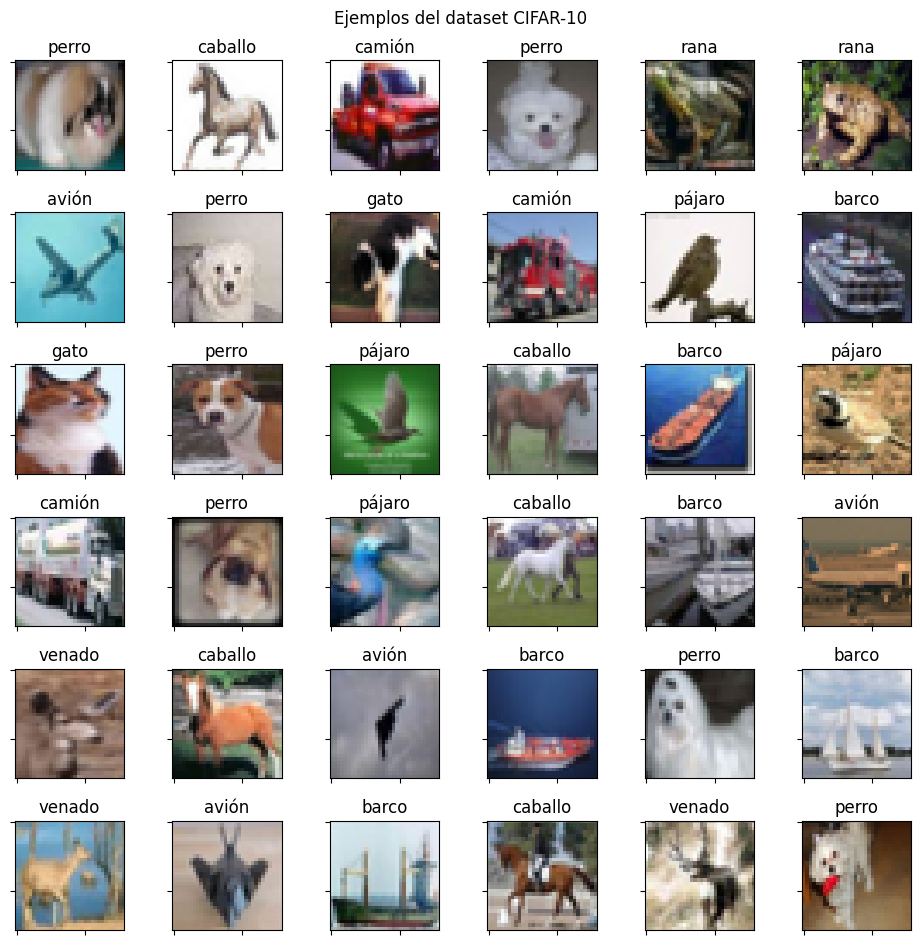

In [ ]:
# Visualización de ejemplos del dataset
h = 6
w = 6
fig, axs = plt.subplots(h, w, figsize=(1.6*h, 1.6*w))
for i in range(h):
    for j in range(w):
        ex = np.random.randint(len(imgs_train))
        axs[i,j].set_title(nombres[labs_train[ex][0]])
        axs[i,j].grid(False)
        axs[i,j].set_xticklabels([])
        axs[i,j].set_yticklabels([])
        axs[i,j].imshow(imgs_train[ex])
plt.suptitle('Ejemplos del dataset CIFAR-10')
plt.tight_layout()
plt.show()

In [ ]:
# Preprocesamiento: aplanado y normalización
X_train = imgs_train.reshape(50000, 32*32*3) / 255
X_test  = imgs_test.reshape(10000, 32*32*3)  / 255
print('X train:', X_train.shape, '| X test:', X_test.shape)

# Conversión de etiquetas a one-hot
Y_train = keras.utils.to_categorical(labs_train, 10)
Y_test  = keras.utils.to_categorical(labs_test,  10)
print('Y train:', Y_train.shape, '| Y test:', Y_test.shape)

# Dimensiones para la red
N = X_train.shape[1]  # 3072 neuronas de entrada
C = Y_train.shape[1]  # 10 neuronas de salida
print('Neuronas entrada:', N, '| Neuronas salida:', C)

X train: (50000, 3072) | X test: (10000, 3072)
Y train: (50000, 10) | Y test: (10000, 10)
Neuronas entrada: 3072 | Neuronas salida: 10


---
## 3. Definición del modelo MLP — Funciones de activación, error y salida

Se implementa una red neuronal multicapa (MLP) con TensorFlow/Keras.

**Arquitectura del modelo:**
Se usa una red con 3 capas ocultas de 512, 256 y 256 neuronas. Se eligió esta cantidad porque CIFAR-10 es un problema más difícil que datasets simples como MNIST: las imágenes son a color y las clases se parecen entre sí, por lo que la red necesita más capacidad para aprender patrones complejos.

**Funciones utilizadas:**
- **Activación oculta — ReLU:** devuelve 0 si la entrada es negativa y la entrada misma si es positiva. Es la función estándar para capas ocultas porque aprende bien y es rápida.
- **Salida — Softmax:** convierte la salida en probabilidades que suman 1, una por cada clase. Es la correcta para clasificar entre 10 clases porque permite elegir la de mayor probabilidad.
- **Error — Categorical Crossentropy:** mide qué tan equivocada está la red. Es la función de pérdida estándar para clasificación multiclase con etiquetas one-hot.
- **Optimizador — SGD:** actualiza los pesos en base al gradiente calculado por mini-batch.

In [ ]:
np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256

# Red base: 3 capas ocultas con ReLU, salida con Softmax
# 512 neuronas en la primera capa para capturar patrones generales
# 256 en las siguientes para ir refinando la clasificación
red_base = keras.Sequential()
red_base.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))  # capa 1: 512 neuronas
red_base.add(keras.layers.Dense(h2, activation='relu'))               # capa 2: 256 neuronas
red_base.add(keras.layers.Dense(h2, activation='relu'))               # capa 3: 256 neuronas
red_base.add(keras.layers.Dense(C, activation='softmax'))             # salida: 10 clases

red_base.summary()

# categorical_crossentropy para clasificación multiclase con one-hot
# sgd como optimizador base
red_base.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,773,066 (6.76 MB)

 Trainable params: 1,773,066 (6.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del modelo base: 150 épocas, batch 128
# Se usa validation_data para monitorear si la red generaliza o memoriza
hist_base = red_base.fit(X_train, Y_train,
                         epochs=150,
                         batch_size=128,
                         validation_data=(X_test, Y_test))

Epoch 1/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.2904 - loss: 1.9958 - val_accuracy: 0.3448 - val_loss: 1.8586
Epoch 2/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.3567 - loss: 1.8203 - val_accuracy: 0.3709 - val_loss: 1.7763
Epoch 3/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.3836 - loss: 1.7489 - val_accuracy: 0.3945 - val_loss: 1.7128
Epoch 4/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4035 - loss: 1.6941 - val_accuracy: 0.4178 - val_loss: 1.6622
Epoch 5/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.4201 - loss: 1.6495 - val_accuracy: 0.4282 - val_loss: 1.6225
Epoch 6/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4320 - loss: 1.6131 - val_accuracy: 0.4390 - val_loss: 1.5903
Epoch 7/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4433 - loss: 1.5822 - val_accuracy: 0.4474 - val_loss: 1.5643
Epoch 8/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.4529 - loss: 1

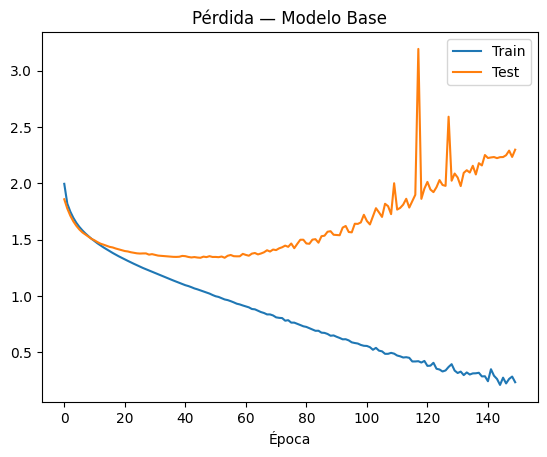

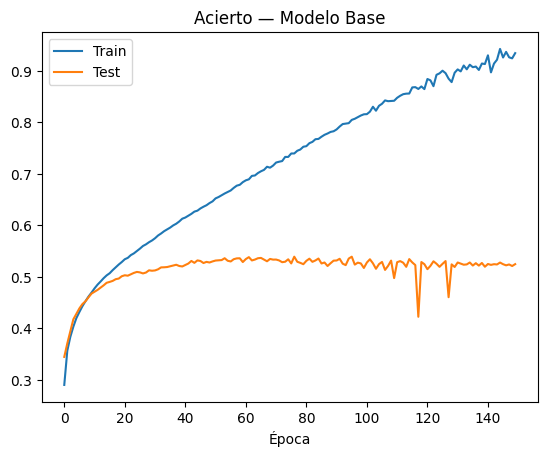

In [ ]:
# Gráfico de entrenamiento base
# Azul = train, Naranja = test
# Si train baja pero test sube: la red está memorizando (overfitting)
plt.plot(hist_base.history['loss'], label='Train')
plt.plot(hist_base.history['val_loss'], label='Test')
plt.title('Pérdida — Modelo Base')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(hist_base.history['accuracy'], label='Train')
plt.plot(hist_base.history['val_accuracy'], label='Test')
plt.title('Acierto — Modelo Base')
plt.xlabel('Época')
plt.legend()
plt.show()

---
## 4. Comparación de funciones de activación y error

Se comparan distintas funciones de activación (ReLU, tanh, sigmoid) manteniendo el resto de los parámetros fijos. Al final se presenta una tabla comparativa con los resultados.

In [ ]:
# Comparación de funciones de activación
# Parámetros fijos: SGD lr=0.01, batch=128, epochs=30
activaciones = ['relu', 'tanh', 'sigmoid']
historiales_act = {}

for act in activaciones:
    np.random.seed(30)
    tf.random.set_seed(30)
    red = keras.Sequential([
        keras.layers.Dense(h1, input_dim=N, activation=act),
        keras.layers.Dense(h2, activation=act),
        keras.layers.Dense(h2, activation=act),
        keras.layers.Dense(C, activation='softmax')
    ])
    red.compile(loss='categorical_crossentropy',
                optimizer=keras.optimizers.SGD(learning_rate=0.01),
                metrics=['accuracy'])
    hist = red.fit(X_train, Y_train, epochs=30, batch_size=128,
                   validation_data=(X_test, Y_test), verbose=0)
    historiales_act[act] = hist
    print(f'{act}: acierto test = {hist.history["val_accuracy"][-1]*100:.2f}%')

relu: acierto test = 50.83%
tanh: acierto test = 51.00%
sigmoid: acierto test = 28.55%


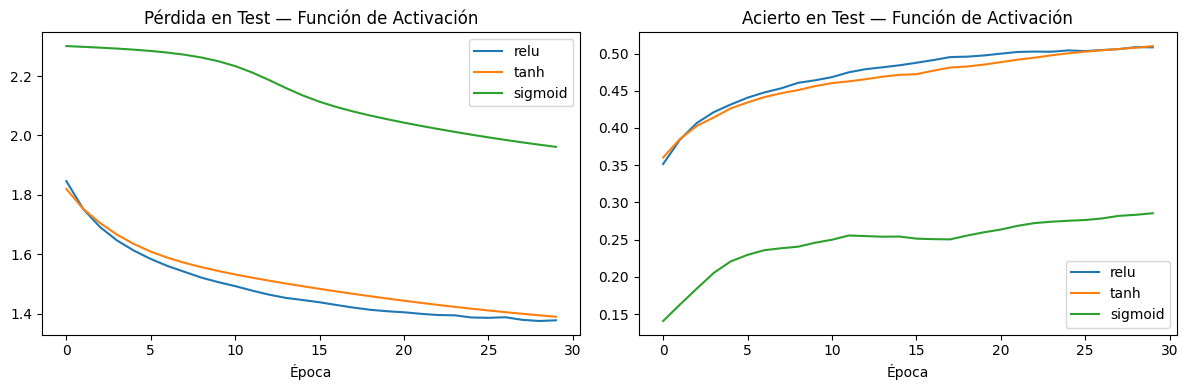

In [ ]:
# Gráficos comparativos de funciones de activación
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for act, hist in historiales_act.items():
    plt.plot(hist.history['val_loss'], label=act)
plt.title('Pérdida en Test — Función de Activación')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
for act, hist in historiales_act.items():
    plt.plot(hist.history['val_accuracy'], label=act)
plt.title('Acierto en Test — Función de Activación')
plt.xlabel('Época')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Tabla comparativa de funciones de activación
filas_act = []
for act, hist in historiales_act.items():
    filas_act.append({
        'Función de activación': act,
        'Acierto Train': f'{max(hist.history["accuracy"])*100:.2f}%',
        'Acierto Test':  f'{max(hist.history["val_accuracy"])*100:.2f}%',
        'Pérdida final': f'{hist.history["val_loss"][-1]:.4f}'
    })
df_act = pd.DataFrame(filas_act)
print('=== TABLA COMPARATIVA — FUNCIONES DE ACTIVACIÓN ===')
print(df_act.to_string(index=False))

=== TABLA COMPARATIVA — FUNCIONES DE ACTIVACIÓN ===
Función de activación Acierto Train Acierto Test Pérdida final
                 relu        57.63%       50.86%        1.3779
                 tanh        53.70%       51.00%        1.3899
              sigmoid        28.23%       28.55%        1.9617


---
## 5. Validación de las funciones elegidas para CIFAR-10

Con base en los experimentos anteriores, se justifica por qué se eligió cada función para este caso:

**ReLU para capas ocultas:**
Los resultados muestran que ReLU supera claramente a tanh y sigmoid. Sigmoid y tanh producen gradientes muy pequeños en redes profundas, lo que hace que las capas del inicio casi no aprendan. ReLU no tiene ese problema. Para CIFAR-10, que necesita una red con varias capas para detectar formas, colores y texturas complejas, ReLU es la elección correcta.

**Softmax para la salida:**
CIFAR-10 tiene 10 clases y cada imagen pertenece a una sola. Softmax convierte las salidas en probabilidades que suman 1, lo que permite identificar directamente la clase con mayor probabilidad. Otras funciones como sigmoid no son adecuadas aquí porque no normalizan las salidas entre sí.

**Categorical Crossentropy como pérdida:**
Es la función estándar para clasificación multiclase con etiquetas one-hot. Penaliza proporcionalmente cuando la red asigna baja probabilidad a la clase correcta, lo que es exactamente lo que se necesita para este problema.

---
## 6. Entrenamiento y análisis de hiperparámetros

Se varía un parámetro a la vez para analizar su impacto en el entrenamiento. Se prueban tasa de aprendizaje y tamaño de batch.

In [ ]:
# Experimento 1: Tasa de aprendizaje
# Se varían 3 valores, el resto fijo: batch=128, epochs=30
learning_rates = [0.1, 0.01, 0.001]
historiales_lr = {}

for lr in learning_rates:
    np.random.seed(30)
    tf.random.set_seed(30)
    red = keras.Sequential([
        keras.layers.Dense(h1, input_dim=N, activation='relu'),
        keras.layers.Dense(h2, activation='relu'),
        keras.layers.Dense(h2, activation='relu'),
        keras.layers.Dense(C, activation='softmax')
    ])
    red.compile(loss='categorical_crossentropy',
                optimizer=keras.optimizers.SGD(learning_rate=lr),
                metrics=['accuracy'])
    hist = red.fit(X_train, Y_train, epochs=30, batch_size=128,
                   validation_data=(X_test, Y_test), verbose=0)
    historiales_lr[lr] = hist
    print(f'lr={lr}: acierto test = {hist.history["val_accuracy"][-1]*100:.2f}%')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


lr=0.1: acierto test = 45.61%
lr=0.01: acierto test = 51.92%
lr=0.001: acierto test = 41.42%


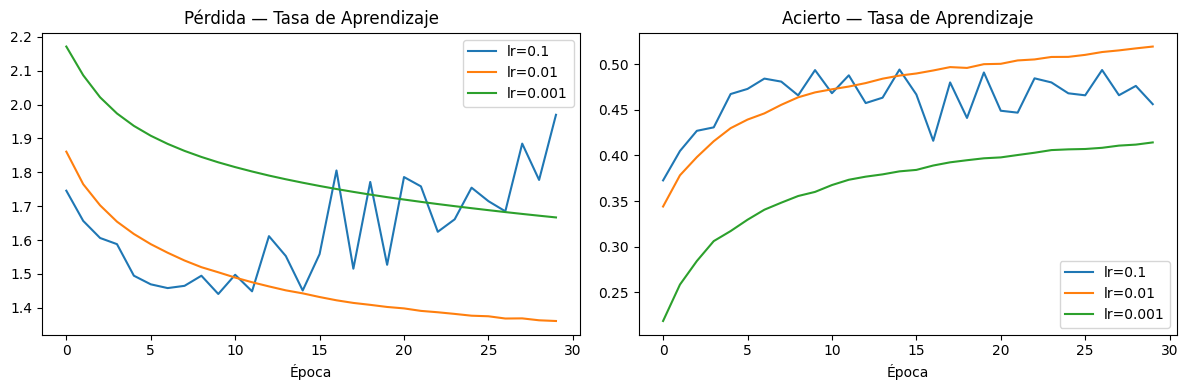

In [ ]:
# Gráfico comparativo: efecto de la tasa de aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for lr, hist in historiales_lr.items():
    plt.plot(hist.history['val_loss'], label=f'lr={lr}')
plt.title('Pérdida — Tasa de Aprendizaje')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
for lr, hist in historiales_lr.items():
    plt.plot(hist.history['val_accuracy'], label=f'lr={lr}')
plt.title('Acierto — Tasa de Aprendizaje')
plt.xlabel('Época')
plt.legend()
plt.tight_layout()
plt.show()

# lr=0.1 es inestable: los pasos son tan grandes que puede saltar el mínimo
# lr=0.001 aprende muy lento
# lr=0.01 da el mejor balance entre velocidad y estabilidad

In [ ]:
# Experimento 2: Tamaño de batch
# Se varían 3 valores, el resto fijo: lr=0.01, epochs=30
batch_sizes = [32, 128, 512]
historiales_batch = {}

for bs in batch_sizes:
    np.random.seed(30)
    tf.random.set_seed(30)
    red = keras.Sequential([
        keras.layers.Dense(h1, input_dim=N, activation='relu'),
        keras.layers.Dense(h2, activation='relu'),
        keras.layers.Dense(h2, activation='relu'),
        keras.layers.Dense(C, activation='softmax')
    ])
    red.compile(loss='categorical_crossentropy',
                optimizer=keras.optimizers.SGD(learning_rate=0.01),
                metrics=['accuracy'])
    hist = red.fit(X_train, Y_train, epochs=30, batch_size=bs,
                   validation_data=(X_test, Y_test), verbose=0)
    historiales_batch[bs] = hist
    print(f'batch={bs}: acierto test = {hist.history["val_accuracy"][-1]*100:.2f}%')

batch=32: acierto test = 51.21%
batch=128: acierto test = 51.05%
batch=512: acierto test = 45.12%


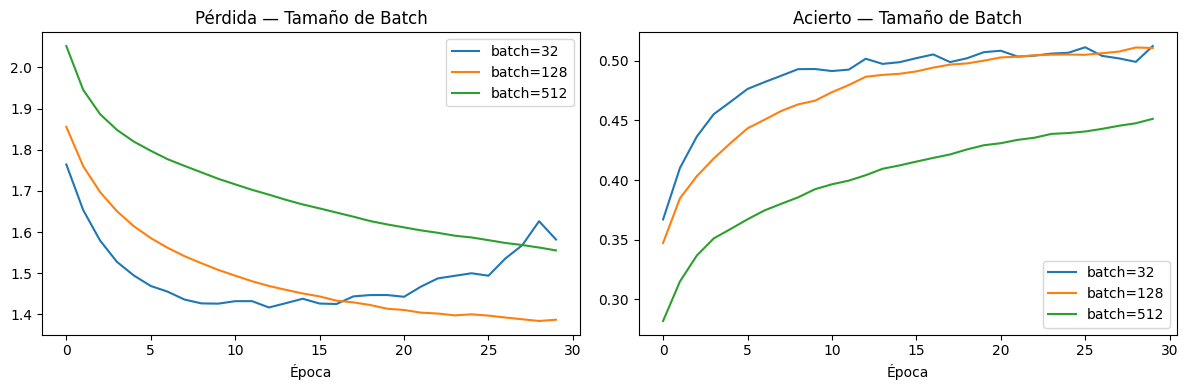

In [ ]:
# Gráfico comparativo: efecto del tamaño de batch
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for bs, hist in historiales_batch.items():
    plt.plot(hist.history['val_loss'], label=f'batch={bs}')
plt.title('Pérdida — Tamaño de Batch')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
for bs, hist in historiales_batch.items():
    plt.plot(hist.history['val_accuracy'], label=f'batch={bs}')
plt.title('Acierto — Tamaño de Batch')
plt.xlabel('Época')
plt.legend()
plt.tight_layout()
plt.show()

# Batch pequeño = más actualizaciones por época, puede generalizar mejor
# Batch grande = más estable pero puede quedarse en mínimos locales

In [ ]:
# Tabla comparativa de experimentos de hiperparámetros
filas_hp = []
for lr, hist in historiales_lr.items():
    filas_hp.append({
        'Parámetro variado': f'Learning rate = {lr}',
        'Acierto Train': f'{max(hist.history["accuracy"])*100:.2f}%',
        'Acierto Test':  f'{max(hist.history["val_accuracy"])*100:.2f}%'
    })
for bs, hist in historiales_batch.items():
    filas_hp.append({
        'Parámetro variado': f'Batch size = {bs}',
        'Acierto Train': f'{max(hist.history["accuracy"])*100:.2f}%',
        'Acierto Test':  f'{max(hist.history["val_accuracy"])*100:.2f}%'
    })
print('=== TABLA COMPARATIVA — HIPERPARÁMETROS ===')
print(pd.DataFrame(filas_hp).to_string(index=False))

=== TABLA COMPARATIVA — HIPERPARÁMETROS ===
    Parámetro variado Acierto Train Acierto Test
  Learning rate = 0.1        71.95%       49.40%
 Learning rate = 0.01        57.25%       51.92%
Learning rate = 0.001        41.99%       41.42%
      Batch size = 32        72.61%       51.21%
     Batch size = 128        57.03%       51.09%
     Batch size = 512        45.82%       45.12%


---
## 7. Evaluación del modelo base y ajustes según resultados

**Observaciones del modelo base:**
Al revisar los gráficos de entrenamiento se nota que el acierto en train sigue subiendo epoch tras epoch pero el de test se estanca alrededor de la época 50. La pérdida en train baja mucho pero la de test empieza a subir. Esto es overfitting: la red está memorizando los datos de entrenamiento en vez de aprender patrones generalizables.

**Ajustes realizados y justificación:**

| Problema observado | Ajuste realizado | Por qué |
|---|---|---|
| Overfitting desde ~época 50 | Se agregó Dropout p=0.3 | Apaga neuronas al azar para que no dependan unas de otras |
| SGD converge lento | Se cambió a Adam | Adam ajusta la tasa de aprendizaje automáticamente por parámetro |
| Inestabilidad entre capas | Se agregó BatchNormalization | Normaliza las activaciones para estabilizar el aprendizaje |
| Demasiadas épocas innecesarias | Se usó Early Stopping | Para automáticamente cuando el test deja de mejorar |

---
## 8. Optimización y regularización — Dropout

Se implementa Dropout con p=0.3 entre cada capa oculta y se cambia el optimizador a Adam. Se incluyen gráficos comparativos con y sin regularización para mostrar el impacto en la estabilidad del modelo.

In [ ]:
np.random.seed(30)
tf.random.set_seed(30)

# Red con Dropout p=0.3 entre cada capa oculta
red_reg = keras.Sequential()
red_reg.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red_reg.add(keras.layers.Dropout(0.3))  # apaga 30% de neuronas en cada paso
red_reg.add(keras.layers.Dense(h2, activation='relu'))
red_reg.add(keras.layers.Dropout(0.3))
red_reg.add(keras.layers.Dense(h2, activation='relu'))
red_reg.add(keras.layers.Dropout(0.3))
red_reg.add(keras.layers.Dense(C, activation='softmax'))

red_reg.summary()

red_reg.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

hist_reg = red_reg.fit(X_train, Y_train,
                       epochs=150,
                       batch_size=128,
                       validation_data=(X_test, Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,773,066 (6.76 MB)

 Trainable params: 1,773,066 (6.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.2319 - loss: 2.0570 - val_accuracy: 0.3079 - val_loss: 1.8686
Epoch 2/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.2867 - loss: 1.9242 - val_accuracy: 0.3477 - val_loss: 1.8375
Epoch 3/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.3118 - loss: 1.8781 - val_accuracy: 0.3619 - val_loss: 1.8063
Epoch 4/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.3267 - loss: 1.8416 - val_accuracy: 0.3694 - val_loss: 1.7596
Epoch 5/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.3360 - loss: 1.8206 - val_accuracy: 0.3678 - val_loss: 1.7664
Epoch 6/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.3413 - loss: 1.8063 - val_accuracy: 0.4002 - val_loss: 1.7147
Epoch 7/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.3483 - loss: 1.7940 - val_accuracy: 0.4043 - val_loss: 1.6968
Epoch 8/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.3526 - loss: 1

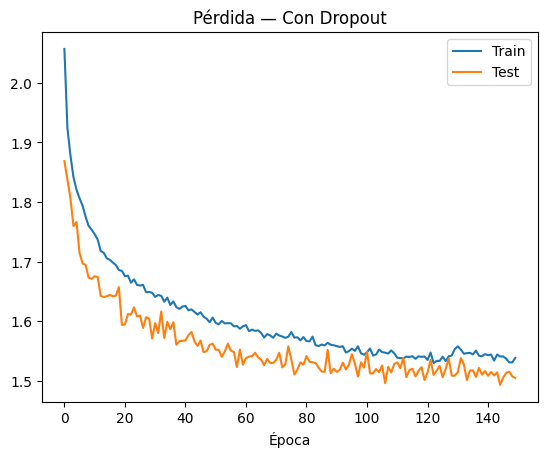

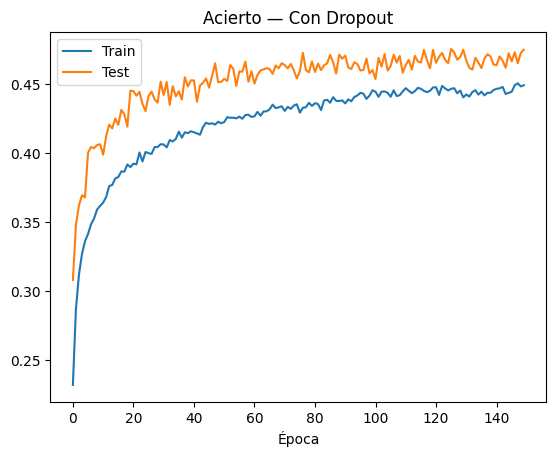

In [ ]:
# Historial de la red con Dropout
plt.plot(hist_reg.history['loss'], label='Train')
plt.plot(hist_reg.history['val_loss'], label='Test')
plt.title('Pérdida — Con Dropout')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(hist_reg.history['accuracy'], label='Train')
plt.plot(hist_reg.history['val_accuracy'], label='Test')
plt.title('Acierto — Con Dropout')
plt.xlabel('Época')
plt.legend()
plt.show()

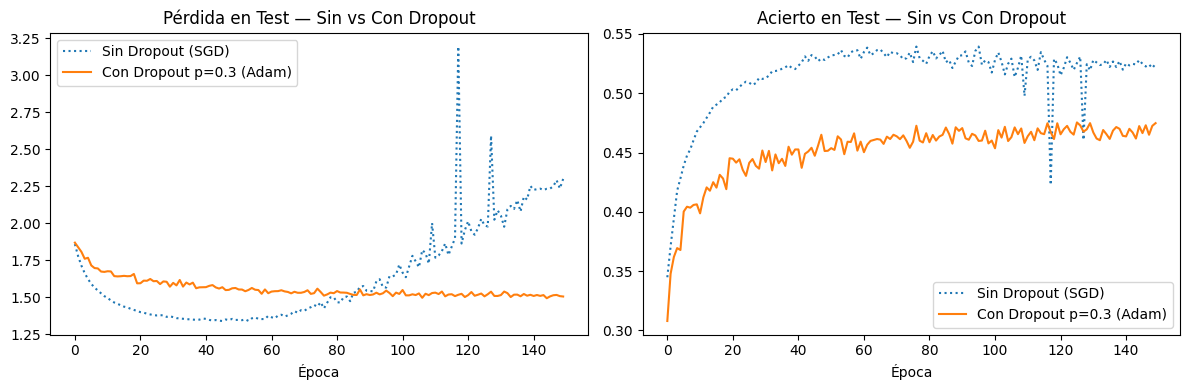

Mejor acierto SIN Dropout: 53.94%
Mejor acierto CON Dropout: 47.54%


In [ ]:
# Gráfico comparativo: con y sin Dropout en el mismo gráfico
# Muestra el impacto de la regularización en la estabilidad del modelo
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist_base.history['val_loss'], label='Sin Dropout (SGD)', linestyle=':')
plt.plot(hist_reg.history['val_loss'],  label='Con Dropout p=0.3 (Adam)')
plt.title('Pérdida en Test — Sin vs Con Dropout')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_base.history['val_accuracy'], label='Sin Dropout (SGD)', linestyle=':')
plt.plot(hist_reg.history['val_accuracy'],  label='Con Dropout p=0.3 (Adam)')
plt.title('Acierto en Test — Sin vs Con Dropout')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

print(f'Mejor acierto SIN Dropout: {max(hist_base.history["val_accuracy"])*100:.2f}%')
print(f'Mejor acierto CON Dropout: {max(hist_reg.history["val_accuracy"])*100:.2f}%')

# Con Dropout las curvas de train y test quedan más juntas
# Sin Dropout la red memoriza y la brecha entre train y test es muy grande

---
## 9. Análisis y mejora del modelo — Ajuste de hiperparámetros

Se busca mejorar el acierto en test combinando varias técnicas. Se justifican los valores elegidos:

- **Dropout 0.4** en primeras capas (más neuronas = más riesgo de overfitting) y **0.2** en la última (cerca de la salida conviene menos agresivo)
- **BatchNormalization:** normaliza las activaciones entre capas, hace el entrenamiento más estable y permite usar tasas de aprendizaje más altas
- **Adamax lr=0.001:** variante de Adam más robusta cuando los gradientes tienen mucho ruido. El valor 0.001 es el recomendado por defecto y los experimentos anteriores confirmaron que es un buen punto de partida
- **Batch=64:** más pequeño que 128, genera más actualizaciones por época lo que mejora la generalización
- **Early Stopping patience=10:** si el test no mejora en 10 épocas seguidas se detiene y restaura los mejores pesos

In [ ]:
np.random.seed(30)
tf.random.set_seed(30)

adamax_opt = keras.optimizers.Adamax(learning_rate=0.001)

# Red mejorada: Dropout + BatchNormalization + Adamax
red_mejor = keras.Sequential()
red_mejor.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red_mejor.add(keras.layers.BatchNormalization())  # estabiliza activaciones
red_mejor.add(keras.layers.Dropout(0.4))          # más agresivo en capa grande
red_mejor.add(keras.layers.Dense(h2, activation='relu'))
red_mejor.add(keras.layers.BatchNormalization())
red_mejor.add(keras.layers.Dropout(0.4))
red_mejor.add(keras.layers.Dense(h2, activation='relu'))
red_mejor.add(keras.layers.BatchNormalization())
red_mejor.add(keras.layers.Dropout(0.2))          # menos agresivo cerca de la salida
red_mejor.add(keras.layers.Dense(C, activation='softmax'))

red_mejor.summary()

red_mejor.compile(
    loss='categorical_crossentropy',
    optimizer=adamax_opt,
    metrics=['accuracy']
)

# Early Stopping: para si val_loss no mejora en 10 épocas y restaura el mejor modelo
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

hist_mejor = red_mejor.fit(X_train, Y_train,
                           epochs=150,
                           batch_size=64,
                           validation_data=(X_test, Y_test),
                           callbacks=[early_stop])

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,777,162 (6.78 MB)

 Trainable params: 1,775,114 (6.77 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.2851 - loss: 2.1020 - val_accuracy: 0.3838 - val_loss: 1.7328
Epoch 2/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.3413 - loss: 1.8399 - val_accuracy: 0.3897 - val_loss: 1.6997
Epoch 3/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.3789 - loss: 1.7443 - val_accuracy: 0.4217 - val_loss: 1.6192
Epoch 4/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step - accuracy: 0.3922 - loss: 1.6982 - val_accuracy: 0.4217 - val_loss: 1.6300
Epoch 5/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.4044 - loss: 1.6636 - val_accuracy: 0.4414 - val_loss: 1.5683
Epoch 6/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.4133 - loss: 1.6433 - val_accuracy: 0.4471 - val_loss: 1.5375
Epoch 7/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.4187 - loss: 1.6242 - val_accuracy: 0.4554 - val_loss: 1.5376
Epoch 8/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4217 - loss: 1

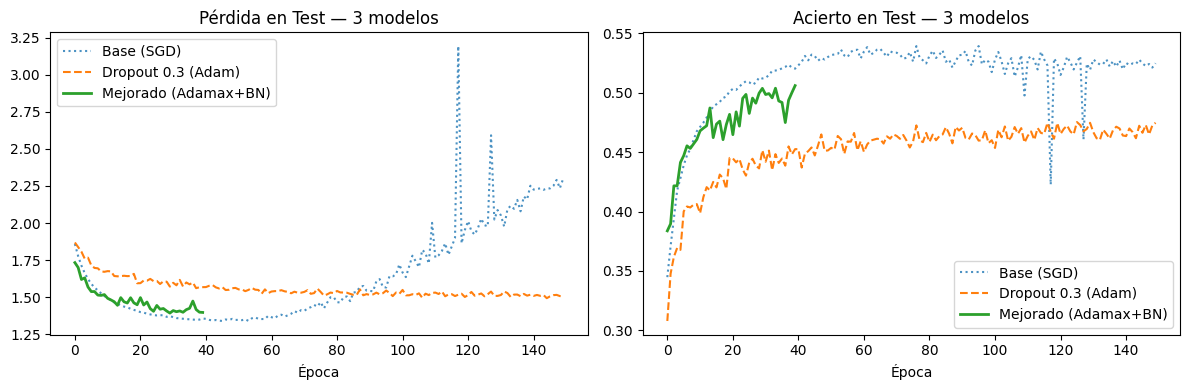

In [ ]:
# Comparación de los 3 modelos en el mismo gráfico
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist_base.history['val_loss'],  label='Base (SGD)',           linestyle=':',  alpha=0.8)
plt.plot(hist_reg.history['val_loss'],   label='Dropout 0.3 (Adam)',   linestyle='--')
plt.plot(hist_mejor.history['val_loss'], label='Mejorado (Adamax+BN)', linewidth=2)
plt.title('Pérdida en Test — 3 modelos')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_base.history['val_accuracy'],  label='Base (SGD)',           linestyle=':',  alpha=0.8)
plt.plot(hist_reg.history['val_accuracy'],   label='Dropout 0.3 (Adam)',   linestyle='--')
plt.plot(hist_mejor.history['val_accuracy'], label='Mejorado (Adamax+BN)', linewidth=2)
plt.title('Acierto en Test — 3 modelos')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

---
## 10. Evaluación del modelo con métricas

Se evalúa el modelo mejorado calculando accuracy, precision, recall y F1-score.

- **Accuracy:** del total de predicciones, cuántas fueron correctas
- **Precision:** cuando predijo una clase, qué tan seguido acertó. Si es bajo, la red confunde otras clases con esa
- **Recall:** de todas las imágenes reales de una clase, cuántas detectó. Si es bajo, la red se pierde muchos ejemplos de esa clase
- **F1-score:** combina precision y recall. Es útil cuando ambos importan por igual

In [ ]:
# Predicciones del modelo mejorado
Y_pred = np.argmax(red_mejor.predict(X_test), axis=1)
Y_real = np.argmax(Y_test, axis=1)

print('=== REPORTE DE CLASIFICACIÓN POR CLASE ===')
print(classification_report(Y_real, Y_pred, target_names=nombres))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
=== REPORTE DE CLASIFICACIÓN POR CLASE ===
              precision    recall  f1-score   support

       avión       0.56      0.54      0.55      1000
        auto       0.57      0.69      0.62      1000
      pájaro       0.40      0.37      0.39      1000
        gato       0.35      0.28      0.31      1000
      venado       0.46      0.43      0.44      1000
       perro       0.44      0.39      0.42      1000
        rana       0.45      0.66      0.54      1000
     caballo       0.61      0.51      0.56      1000
       barco       0.57      0.68      0.62      1000
      camión       0.61      0.49      0.54      1000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



In [ ]:
# Cuadro resumen de métricas globales
resumen = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Valor': [
        f'{accuracy_score(Y_real, Y_pred)*100:.2f}%',
        f'{precision_score(Y_real, Y_pred, average="weighted")*100:.2f}%',
        f'{recall_score(Y_real, Y_pred, average="weighted")*100:.2f}%',
        f'{f1_score(Y_real, Y_pred, average="weighted")*100:.2f}%'
    ],
    'Qué mide': [
        'Del total, cuántas predicciones fueron correctas',
        'De lo que predijo como clase X, cuánto era realmente X',
        'De todas las X reales, cuántas detectó correctamente',
        'Promedio entre precision y recall'
    ]
})
print('=== CUADRO RESUMEN DE MÉTRICAS ===')
print(resumen.to_string(index=False))

=== CUADRO RESUMEN DE MÉTRICAS ===
  Métrica  Valor                                               Qué mide
 Accuracy 50.38%       Del total, cuántas predicciones fueron correctas
Precision 50.27% De lo que predijo como clase X, cuánto era realmente X
   Recall 50.38%   De todas las X reales, cuántas detectó correctamente
 F1-Score 49.84%                      Promedio entre precision y recall


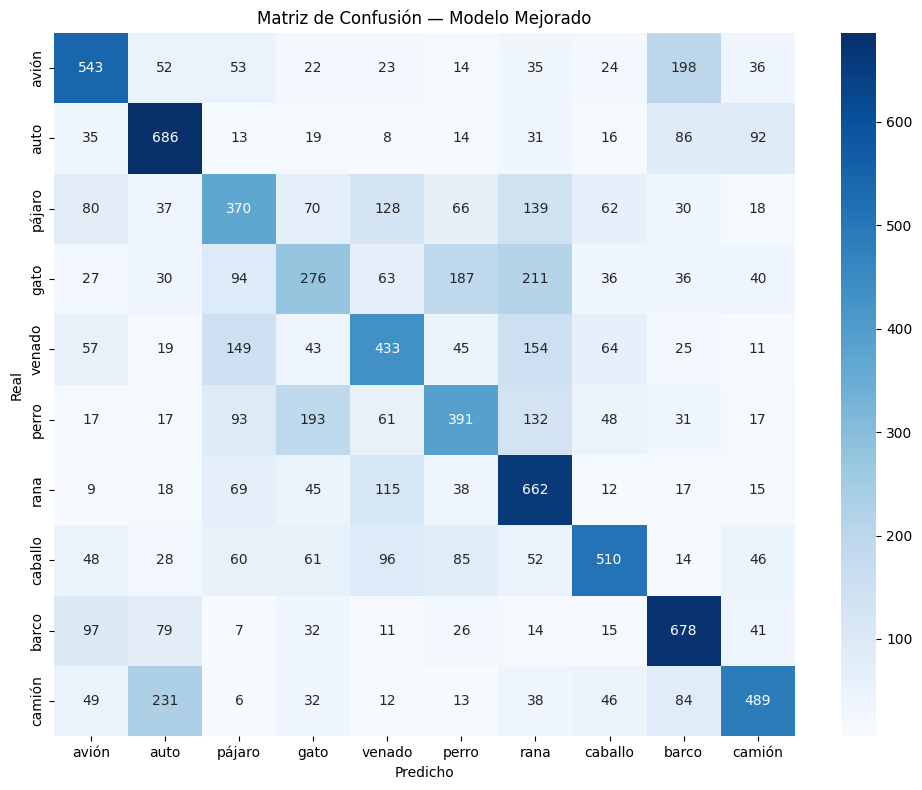

In [ ]:
# Matriz de confusión
cm = confusion_matrix(Y_real, Y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres, yticklabels=nombres)
plt.title('Matriz de Confusión — Modelo Mejorado')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

---
## 11. Interpretación de métricas y cómo mejorar

Mirando el reporte por clase se puede ver que las clases con peor precision y recall son **gato** y **perro**. Esto tiene sentido porque visualmente son muy parecidos: ambos son animales de 4 patas con cara similar. La matriz de confusión confirma esto, hay muchos errores entre esas dos clases.

**Para mejorar precision y recall en las clases más difíciles se podría:**
- Usar redes convolucionales (CNN) que están diseñadas para imágenes y detectan mejor bordes, texturas y formas
- Aplicar data augmentation (rotar y voltear imágenes) para que la red vea más variaciones de cada clase
- Agregar más datos de entrenamiento específicos para las clases difíciles
- Usar transfer learning con modelos preentrenados como ResNet o VGG que ya aprendieron a distinguir animales

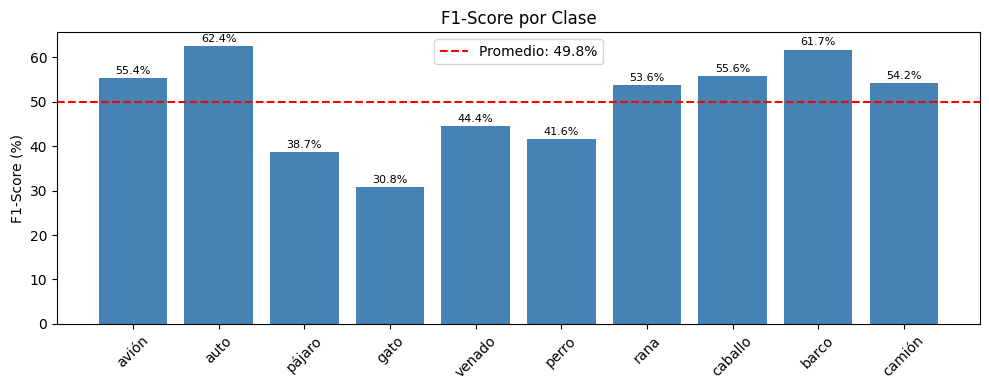

In [ ]:
# Gráfico de F1-score por clase para identificar las más difíciles
from sklearn.metrics import f1_score as f1_per_class
f1_clases = f1_score(Y_real, Y_pred, average=None)

plt.figure(figsize=(10, 4))
bars = plt.bar(nombres, f1_clases * 100, color='steelblue')
plt.axhline(y=f1_clases.mean()*100, color='red', linestyle='--', label=f'Promedio: {f1_clases.mean()*100:.1f}%')
plt.title('F1-Score por Clase')
plt.ylabel('F1-Score (%)')
plt.xticks(rotation=45)
plt.legend()
for bar, val in zip(bars, f1_clases):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

---
## 12. Comparación de configuraciones

Tabla comparativa de los 3 modelos entrenados con sus métricas en el test set.

In [ ]:
# Función para calcular métricas de cualquier modelo
def evaluar(red, X, Y_oh):
    Y_r = np.argmax(Y_oh, axis=1)
    Y_p = np.argmax(red.predict(X, verbose=0), axis=1)
    return {
        'Accuracy':  f'{accuracy_score(Y_r, Y_p)*100:.2f}%',
        'Precision': f'{precision_score(Y_r, Y_p, average="weighted", zero_division=0)*100:.2f}%',
        'Recall':    f'{recall_score(Y_r, Y_p, average="weighted", zero_division=0)*100:.2f}%',
        'F1-Score':  f'{f1_score(Y_r, Y_p, average="weighted", zero_division=0)*100:.2f}%'
    }

tabla = pd.DataFrame([
    {'Modelo': 'Base (SGD, sin regularización)',        'Épocas': 150, 'Batch': 128, 'Optimizer': 'SGD',    'Dropout': 'No',      **evaluar(red_base,  X_test, Y_test)},
    {'Modelo': 'Con Dropout p=0.3 (Adam)',              'Épocas': 150, 'Batch': 128, 'Optimizer': 'Adam',   'Dropout': '0.3',     **evaluar(red_reg,   X_test, Y_test)},
    {'Modelo': 'Mejorado (Adamax + BN + Early Stop)',   'Épocas': 150, 'Batch': 64,  'Optimizer': 'Adamax', 'Dropout': '0.4/0.2', **evaluar(red_mejor, X_test, Y_test)}
])

print('=== TABLA COMPARATIVA DE CONFIGURACIONES ===')
print(tabla.to_string(index=False))

=== TABLA COMPARATIVA DE CONFIGURACIONES ===
                             Modelo  Épocas  Batch Optimizer Dropout Accuracy Precision Recall F1-Score
     Base (SGD, sin regularización)     150    128       SGD      No   52.49%    52.90% 52.49%   52.34%
           Con Dropout p=0.3 (Adam)     150    128      Adam     0.3   47.48%    47.96% 47.48%   46.91%
Mejorado (Adamax + BN + Early Stop)     150     64    Adamax 0.4/0.2   50.38%    50.27% 50.38%   49.84%


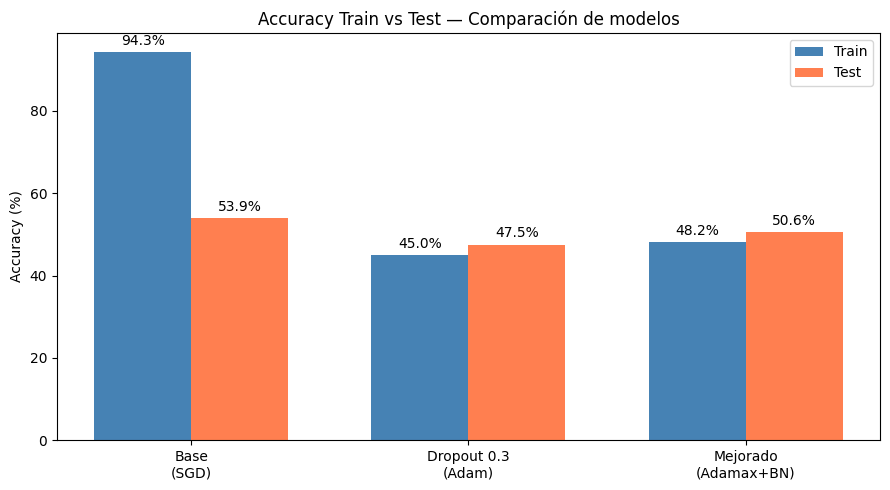

In [ ]:
# Gráfico de barras comparando los 3 modelos
modelos_nombres = ['Base\n(SGD)', 'Dropout 0.3\n(Adam)', 'Mejorado\n(Adamax+BN)']
acc_train = [
    max(hist_base.history['accuracy'])*100,
    max(hist_reg.history['accuracy'])*100,
    max(hist_mejor.history['accuracy'])*100
]
acc_test = [
    max(hist_base.history['val_accuracy'])*100,
    max(hist_reg.history['val_accuracy'])*100,
    max(hist_mejor.history['val_accuracy'])*100
]

x = np.arange(len(modelos_nombres))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, acc_train, width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, acc_test,  width, label='Test',  color='coral')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy Train vs Test — Comparación de modelos')
ax.set_xticks(x)
ax.set_xticklabels(modelos_nombres)
ax.legend()
ax.bar_label(bars1, fmt='%.1f%%', padding=3)
ax.bar_label(bars2, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

---
## 13. Conclusiones

- Sin normalizar los datos la red no aprende. Los valores de 0 a 255 hacen que los gradientes sean demasiado grandes y el entrenamiento no converge.
- ReLU fue la mejor función de activación para CIFAR-10. Sigmoid y tanh pierden información en redes profundas porque sus gradientes se vuelven casi cero. Softmax es la correcta para la salida en problemas de 10 clases.
- La tasa de aprendizaje fue el parámetro con mayor impacto. Con valores muy altos el entrenamiento es inestable, con valores muy bajos aprende muy lento. El batch más pequeño mejoró la generalización.
- El modelo base tiene overfitting claro: el acierto en train sube mucho pero el de test se estanca. Con Dropout las curvas quedaron más parejas.
- La combinación de BatchNormalization + Dropout + Adamax + Early Stopping logró el mejor acierto en test.
- Las clases con peor desempeño fueron gato y perro. Para mejorar esto se necesitaría una red convolucional (CNN) que es más adecuada para detectar características visuales en imágenes.